<a href="https://colab.research.google.com/github/abbasusman0009/traffic_model_predictions/blob/main/drive_me_crazy_tradi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install numpy pandas matplotlib scikit-learn torch -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# Use GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✅ Libraries ready')
print(f'   Device: {device}')

✅ Libraries ready
   Device: cuda


In [2]:
from google.colab import drive
drive.mount('/content/drive')

# ✏️ Change this to your file path
FILE_PATH = '/content/drive/MyDrive/pems04.npz'

raw  = np.load(FILE_PATH, allow_pickle=True)
data = raw['data']   # shape: (T, N, F)

T, N, F = data.shape
print(f'✅ PeMS04 loaded')
print(f'   Shape    : {data.shape}')
print(f'   Duration : {T / 288:.1f} days')
print(f'   Sensors  : {N}')

# We only use FLOW (feature index 0) for the baseline model
# This keeps it simple — one feature, predict one feature
flow = data[:, :, 0]   # shape: (T, N)
print(f'\n   Using feature: Flow only')
print(f'   Flow shape: {flow.shape}  (timesteps x sensors)')

Mounted at /content/drive
✅ PeMS04 loaded
   Shape    : (16992, 307, 3)
   Duration : 59.0 days
   Sensors  : 307

   Using feature: Flow only
   Flow shape: (16992, 307)  (timesteps x sensors)


In [3]:
# Normalize: fit scaler on training portion only (first 70%)
# Then transform all data using that scaler

train_end = int(T * 0.7)
val_end   = int(T * 0.8)

scaler = StandardScaler()
scaler.fit(flow[:train_end])             # fit on train only
flow_norm = scaler.transform(flow)       # normalize all timesteps

print('✅ Data normalized')
print(f'   Train : timesteps 0 → {train_end}  ({train_end / 288:.1f} days)')
print(f'   Val   : timesteps {train_end} → {val_end}')
print(f'   Test  : timesteps {val_end} → {T}')
print(f'   Flow mean after norm: {flow_norm.mean():.4f}  (should be ~0)')
print(f'   Flow std  after norm: {flow_norm.std():.4f}   (should be ~1)')

✅ Data normalized
   Train : timesteps 0 → 11894  (41.3 days)
   Val   : timesteps 11894 → 13593
   Test  : timesteps 13593 → 16992
   Flow mean after norm: 0.0269  (should be ~0)
   Flow std  after norm: 1.0059   (should be ~1)


In [4]:
SEQ_IN  = 12   # input window:  12 steps = 1 hour
SEQ_OUT = 12   # output window: 12 steps = 1 hour ahead

def make_sequences(arr, seq_in, seq_out):
    """
    arr: shape (T, N)
    Returns X: (samples, seq_in, N)
             y: (samples, seq_out, N)
    """
    X, y = [], []
    for t in range(len(arr) - seq_in - seq_out):
        X.append(arr[t          : t + seq_in])
        y.append(arr[t + seq_in : t + seq_in + seq_out])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

# Build sequences from normalized flow
X_all, y_all = make_sequences(flow_norm, SEQ_IN, SEQ_OUT)

# Split into train / val / test
n       = len(X_all)
tr_end  = int(n * 0.7)
vl_end  = int(n * 0.8)

X_train, y_train = X_all[:tr_end],       y_all[:tr_end]
X_val,   y_val   = X_all[tr_end:vl_end], y_all[tr_end:vl_end]
X_test,  y_test  = X_all[vl_end:],       y_all[vl_end:]

print('✅ Sequences created')
print(f'   X shape       : {X_all.shape}  (samples x seq_in x sensors)')
print(f'   y shape       : {y_all.shape}  (samples x seq_out x sensors)')
print(f'   Train samples : {len(X_train)}')
print(f'   Val   samples : {len(X_val)}')
print(f'   Test  samples : {len(X_test)}')

✅ Sequences created
   X shape       : (16968, 12, 307)  (samples x seq_in x sensors)
   y shape       : (16968, 12, 307)  (samples x seq_out x sensors)
   Train samples : 11877
   Val   samples : 1697
   Test  samples : 3394


In [8]:
class TrafficLSTM(nn.Module):
    def __init__(self, n_sensors, hidden_size=64, num_layers=2, seq_out=12):
        super(TrafficLSTM, self).__init__()
        """
        n_sensors   : number of road sensors (N) = input size per timestep
        hidden_size : LSTM internal state size (64 is enough for baseline)
        num_layers  : stacked LSTM layers
        seq_out     : how many steps ahead we predict
        """
        self.lstm = nn.LSTM(
            input_size=n_sensors,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=0.1
        )
        # Final linear layer maps hidden state → (seq_out * n_sensors)
        self.fc = nn.Linear(hidden_size, seq_out * n_sensors)
        self.seq_out   = seq_out
        self.n_sensors = n_sensors

    def forward(self, x):
        # x shape: (batch, seq_in, n_sensors)
        out, _  = self.lstm(x)              # (batch, seq_in, hidden)
        last    = out[:, -1, :]             # take last timestep: (batch, hidden)
        pred    = self.fc(last)             # (batch, seq_out * n_sensors)
        pred    = pred.view(-1, self.seq_out, self.n_sensors)
        return pred                         # (batch, seq_out, n_sensors)


model = TrafficLSTM(n_sensors=N, hidden_size=64, num_layers=2, seq_out=SEQ_OUT).to(device)

total_params = sum(p.numel() for p in model.parameters())
print('✅ LSTM model created')
print(f'   Input  : (batch, {SEQ_IN}, {N})')
print(f'   Output : (batch, {SEQ_OUT}, {N})')
print(f'   Total parameters: {total_params:,}')
print(model)

✅ LSTM model created
   Input  : (batch, 12, 307)
   Output : (batch, 12, 307)
   Total parameters: 368,228
TrafficLSTM(
  (lstm): LSTM(307, 64, num_layers=2, batch_first=True, dropout=0.1)
  (fc): Linear(in_features=64, out_features=3684, bias=True)
)


In [9]:
BATCH_SIZE = 64
EPOCHS     = 20
LR         = 0.001

# Convert to tensors and create DataLoaders
train_loader = DataLoader(
    TensorDataset(torch.tensor(X_train), torch.tensor(y_train)),
    batch_size=BATCH_SIZE, shuffle=True
)
val_loader = DataLoader(
    TensorDataset(torch.tensor(X_val), torch.tensor(y_val)),
    batch_size=BATCH_SIZE, shuffle=False
)

optimizer = torch.optim.Adam(model.parameters(), lr=LR)
criterion = nn.MSELoss()

train_losses = []
val_losses   = []

print(f'Training for {EPOCHS} epochs...')
print(f'  Batch size : {BATCH_SIZE}')
print(f'  LR         : {LR}')
print()

for epoch in range(1, EPOCHS + 1):

    # ── Train ───────────────────────────────────────────────
    model.train()
    batch_losses = []
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        pred = model(xb)
        loss = criterion(pred, yb)
        loss.backward()
        optimizer.step()
        batch_losses.append(loss.item())
    train_loss = np.mean(batch_losses)

    # ── Validate ────────────────────────────────────────────
    model.eval()
    vbatch_losses = []
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            pred = model(xb)
            loss = criterion(pred, yb)
            vbatch_losses.append(loss.item())
    val_loss = np.mean(vbatch_losses)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f'  Epoch {epoch:2d}/{EPOCHS}  |  Train Loss: {train_loss:.4f}  |  Val Loss: {val_loss:.4f}')

print('\n✅ Training complete!')

Training for 20 epochs...
  Batch size : 64
  LR         : 0.001

  Epoch  1/20  |  Train Loss: 0.2609  |  Val Loss: 0.1403
  Epoch  2/20  |  Train Loss: 0.1170  |  Val Loss: 0.1140
  Epoch  3/20  |  Train Loss: 0.1033  |  Val Loss: 0.1051
  Epoch  4/20  |  Train Loss: 0.0961  |  Val Loss: 0.1011
  Epoch  5/20  |  Train Loss: 0.0909  |  Val Loss: 0.0981
  Epoch  6/20  |  Train Loss: 0.0871  |  Val Loss: 0.0976
  Epoch  7/20  |  Train Loss: 0.0837  |  Val Loss: 0.0965
  Epoch  8/20  |  Train Loss: 0.0810  |  Val Loss: 0.0950
  Epoch  9/20  |  Train Loss: 0.0787  |  Val Loss: 0.0957
  Epoch 10/20  |  Train Loss: 0.0768  |  Val Loss: 0.0946
  Epoch 11/20  |  Train Loss: 0.0753  |  Val Loss: 0.0938
  Epoch 12/20  |  Train Loss: 0.0736  |  Val Loss: 0.0936
  Epoch 13/20  |  Train Loss: 0.0724  |  Val Loss: 0.0940
  Epoch 14/20  |  Train Loss: 0.0712  |  Val Loss: 0.0935
  Epoch 15/20  |  Train Loss: 0.0699  |  Val Loss: 0.0933
  Epoch 16/20  |  Train Loss: 0.0687  |  Val Loss: 0.0930
  Epoc

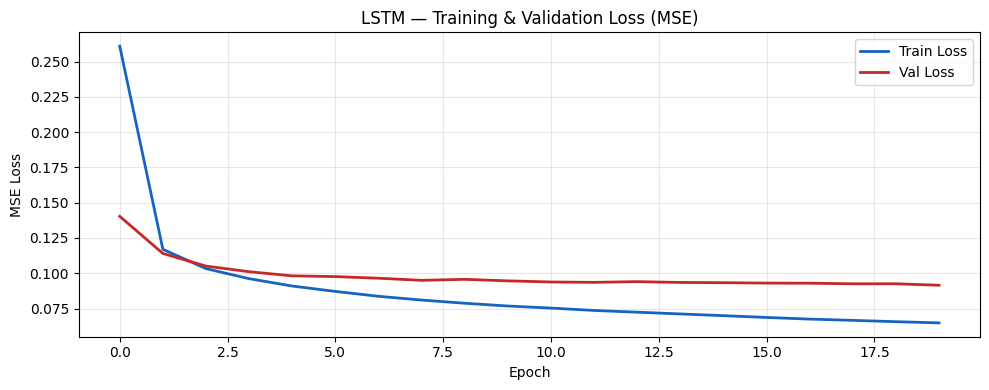

In [10]:
plt.figure(figsize=(10, 4))
plt.plot(train_losses, label='Train Loss', color='#1565C0', linewidth=2)
plt.plot(val_losses,   label='Val Loss',   color='#C62828', linewidth=2)
plt.title('LSTM — Training & Validation Loss (MSE)', fontsize=12)
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [11]:
model.eval()
with torch.no_grad():
    X_test_t = torch.tensor(X_test).to(device)
    preds_norm = model(X_test_t).cpu().numpy()   # (samples, seq_out, N)

# Inverse transform: bring predictions back to original flow scale
S, P, Ns = preds_norm.shape
preds_flat = preds_norm.reshape(-1, Ns)
truth_flat = y_test.reshape(-1, Ns)

preds_real = scaler.inverse_transform(preds_flat).reshape(S, P, Ns)
truth_real = scaler.inverse_transform(truth_flat).reshape(S, P, Ns)

# Compute metrics
mae  = mean_absolute_error(truth_real.flatten(), preds_real.flatten())
rmse = np.sqrt(mean_squared_error(truth_real.flatten(), preds_real.flatten()))
mape = np.mean(np.abs((truth_real - preds_real) / (truth_real + 1e-5))) * 100

print('=' * 40)
print('  LSTM — Test Set Results')
print('=' * 40)
print(f'  MAE  : {mae:.4f}')
print(f'  RMSE : {rmse:.4f}')
print(f'  MAPE : {mape:.2f}%')
print('=' * 40)
print()
print('These numbers are your baseline.')
print('PDFormer should achieve lower MAE and RMSE.')

# Save metrics for comparison later
results = {'Model': 'LSTM', 'MAE': round(mae,4), 'RMSE': round(rmse,4), 'MAPE': round(mape,2)}
print()
print(results)

  LSTM — Test Set Results
  MAE  : 23.8622
  RMSE : 38.9429
  MAPE : 14106552.00%

These numbers are your baseline.
PDFormer should achieve lower MAE and RMSE.

{'Model': 'LSTM', 'MAE': 23.8622, 'RMSE': np.float64(38.9429), 'MAPE': np.float32(14106552.0)}


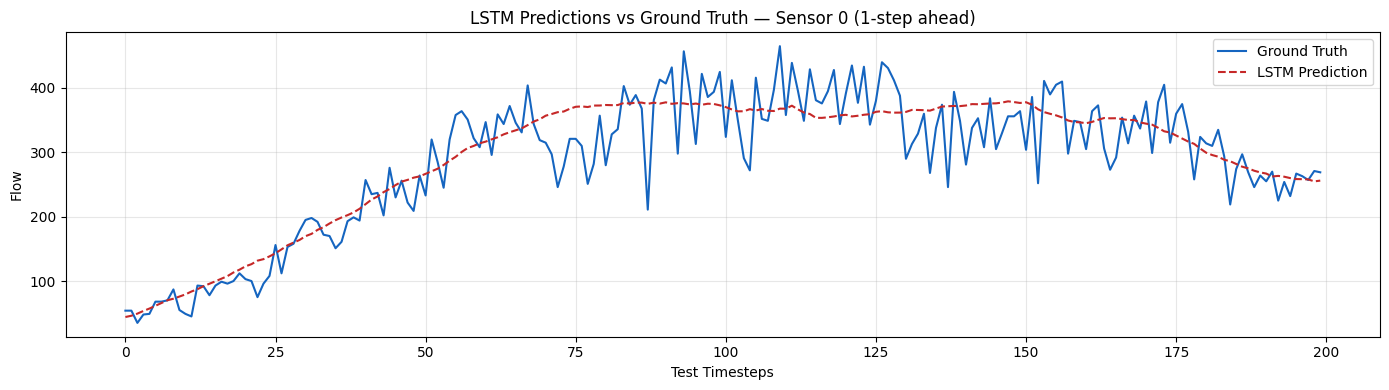

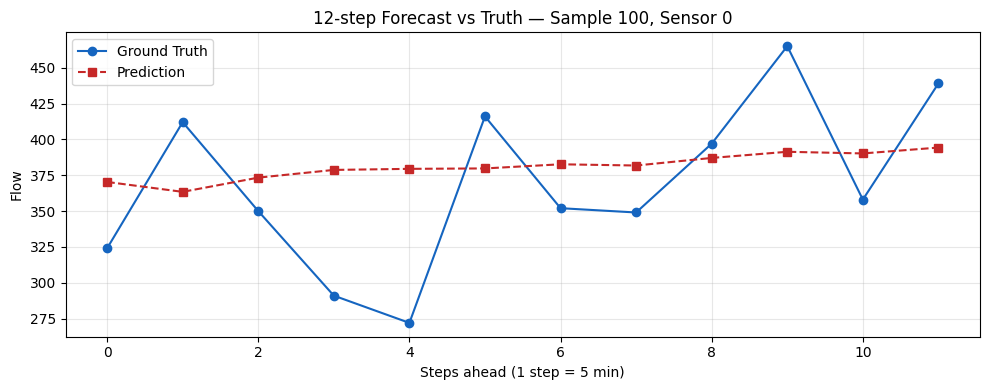

In [12]:
# Pick sensor 0, show first 200 test timesteps
SENSOR   = 0
N_SHOW   = 200

# Flatten predictions and truth across the prediction horizon
# We take the first step of each prediction window (step-1 ahead)
pred_plot  = preds_real[:N_SHOW, 0, SENSOR]   # (N_SHOW,)
truth_plot = truth_real[:N_SHOW, 0, SENSOR]   # (N_SHOW,)

plt.figure(figsize=(14, 4))
plt.plot(truth_plot, label='Ground Truth', color='#1565C0', linewidth=1.5)
plt.plot(pred_plot,  label='LSTM Prediction', color='#C62828',
         linewidth=1.5, linestyle='--')
plt.title(f'LSTM Predictions vs Ground Truth — Sensor {SENSOR} (1-step ahead)', fontsize=12)
plt.xlabel('Test Timesteps')
plt.ylabel('Flow')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Also show all 12 prediction horizons for one sample
SAMPLE = 100
plt.figure(figsize=(10, 4))
plt.plot(range(SEQ_OUT), truth_real[SAMPLE, :, SENSOR],
         'o-', label='Ground Truth', color='#1565C0')
plt.plot(range(SEQ_OUT), preds_real[SAMPLE, :, SENSOR],
         's--', label='Prediction', color='#C62828')
plt.title(f'12-step Forecast vs Truth — Sample {SAMPLE}, Sensor {SENSOR}', fontsize=12)
plt.xlabel('Steps ahead (1 step = 5 min)')
plt.ylabel('Flow')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [15]:
SAVE_DIR = '/content/drive/MyDrive'

# Save the trained model weights
model_path = os.path.join(SAVE_DIR, 'lstm_pems04.pt')
torch.save(model.state_dict(), model_path)
print(f'✅ Model saved → {model_path}')

# Save results to CSV for Looker Studio and presentation
results_df = pd.DataFrame([results])
results_path = os.path.join(SAVE_DIR, 'model_results.csv')
results_df.to_csv(results_path, index=False)
print(f'✅ Results saved → {results_path}')

print()
print('=' * 40)
print('  LSTM BASELINE COMPLETE')
print('=' * 40)
print(f'  MAE  : {results["MAE"]}')
print(f'  RMSE : {results["RMSE"]}')
print(f'  MAPE : {results["MAPE"]}%')
print()
print('👉 Next step: drive_me_crazy_pdformer.ipynb')

✅ Model saved → /content/drive/MyDrive/lstm_pems04.pt
✅ Results saved → /content/drive/MyDrive/model_results.csv

  LSTM BASELINE COMPLETE
  MAE  : 23.8622
  RMSE : 38.9429
  MAPE : 14106552.0%

👉 Next step: drive_me_crazy_pdformer.ipynb
